In [1]:
# Data Analysis libraries
import numpy as np
import pandas as pd

In [2]:
# Data Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configuration
%matplotlib inline
sns.set_style('whitegrid')

In [4]:
# Avoid Warning
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load Dataset
df = pd.read_csv(r'C:\Users\NoteBook\Desktop\traffic_ai_system\dataset\US_Accidents_500k.csv')

In [6]:
# Top five rows
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,6/12/2019 10:10,6/12/2019 10:55,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,37:14.0,56:53.0,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,13:00.0,22:45.0,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2/21/2022 17:43,2/21/2022 19:43,43.680592,-92.993317,43.680574,-92.972223,1.054,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,12/4/2020 1:46,12/4/2020 4:13,35.395484,-118.985176,35.395476,-118.985995,0.046,...,False,False,False,False,False,False,Night,Night,Night,Night


In [7]:
# Rows and columns of dataframe
number_of_rows , number_of_columns = df.shape

In [8]:
print(f'Our dataset has {number_of_rows} rows')
print(f'Our dataset has {number_of_columns} columns')

Our dataset has 500000 rows
Our dataset has 46 columns


In [9]:
# Total Number of Instances of Target class
df['Severity'].value_counts().sort_index()

Severity
1      4274
2    398142
3     84520
4     13064
Name: count, dtype: int64

In [10]:
# Percentage of Instances of Target class
df['Severity'].value_counts(normalize=True).mul(100).sort_index()

Severity
1     0.8548
2    79.6284
3    16.9040
4     2.6128
Name: proportion, dtype: float64

<Axes: xlabel='Severity', ylabel='count'>

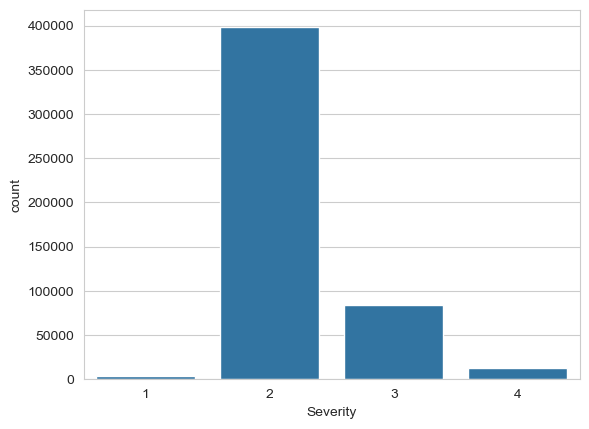

In [11]:
sns.countplot(data=df,x='Severity')

In [12]:
# Check for missing values
df.isnull().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  220377
End_Lng                  220377
Distance(mi)                  0
Description                   1
Street                      691
City                         19
County                        0
State                         0
Zipcode                     116
Country                       0
Timezone                    507
Airport_Code               1446
Weather_Timestamp          7674
Temperature(F)            10466
Wind_Chill(F)            129017
Humidity(%)               11130
Pressure(in)               8928
Visibility(mi)            11291
Wind_Direction            11197
Wind_Speed(mph)           36987
Precipitation(in)        142616
Weather_Condition         11101
Amenity                       0
Bump                          0
Crossing

In [13]:
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

End_Lat                  44.0754
End_Lng                  44.0754
Precipitation(in)        28.5232
Wind_Chill(F)            25.8034
Wind_Speed(mph)           7.3974
Visibility(mi)            2.2582
Wind_Direction            2.2394
Humidity(%)               2.2260
Weather_Condition         2.2202
Temperature(F)            2.0932
Pressure(in)              1.7856
Weather_Timestamp         1.5348
Sunrise_Sunset            0.2966
Civil_Twilight            0.2966
Nautical_Twilight         0.2966
Astronomical_Twilight     0.2966
Airport_Code              0.2892
Street                    0.1382
Timezone                  0.1014
Zipcode                   0.0232
City                      0.0038
Description               0.0002
dtype: float64


In [14]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [15]:
# Cleaning Description column
df = df.dropna(subset=['Description']).copy()

In [16]:
num_cols_with_missing = [
    'Temperature(F)',
    'Humidity(%)',
    'Visibility(mi)',
    'Wind_Speed(mph)'
]

for col in num_cols_with_missing:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [17]:
# Convert Start_Time to datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

In [18]:
# Extract hour , month , weekdays
df['Hour'] = df['Start_Time'].dt.hour
df['Month'] = df['Start_Time'].dt.month
df['Weekday'] = df['Start_Time'].dt.dayofweek

In [19]:
# Now let's delete all the rows that has NAT
df = df.dropna(subset=['Start_Time']).copy()

In [20]:
df.reset_index(drop=True, inplace=True)

In [21]:
# let's see head of time columns
df[['Start_Time', 'Hour', 'Month', 'Weekday']].head()

,Start_Time,Hour,Month,Weekday
0,2019-06-12 10:10:00,10.0,6.0,2.0
1,2022-02-21 17:43:00,17.0,2.0,0.0
2,2020-12-04 01:46:00,1.0,12.0,4.0
3,2021-03-29 07:03:00,7.0,3.0,0.0
4,2020-01-14 16:49:00,16.0,1.0,1.0


In [22]:
print("shape:", df.shape)

shape: (451836, 49)


### Cleaning the texts

In [23]:
# Import libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [24]:
corpus = (
    df['Description']
    .astype(str)
    .str.replace('[^a-zA-Z]', ' ', regex=True)
    .str.lower()
    .str.split()
    .tolist()
)

In [25]:
# Apply Stemming & Stopwords to your corpus
all_stopwords = set(stopwords.words('english'))
all_stopwords -= {"no","not","nor"}
# Road-related words (noise)
ROAD_WORDS = {
    "rd", "st", "ave", "blvd", "dr", "ln", "ct",
    "hwy", "fwy", "pkwy",
    "eb", "wb", "sb", "nb",
    "us", "sr", "rt", "exit","road","street"}
ps = PorterStemmer()
corpus_final = [
    ' '.join([ps.stem(word) for word in sentence if word not in all_stopwords and word not in ROAD_WORDS])
    for sentence in corpus
]

In [26]:
# Save into dataframe
df['Cleaned_Description'] = corpus_final

In [27]:
print("Cleaning Complete!")
df[['Description', 'Cleaned_Description']].head()

Cleaning Complete!


,Description,Cleaned_Description
0,Accident on LA-19 Baker-Zachary Hwy at Lower Z...,accid la baker zachari lower zachari
1,Incident on I-90 EB near REST AREA Drive with ...,incid near rest area drive caution
2,RP ADV THEY LOCATED SUSP VEH OF 20002 - 726 CR...,rp adv locat susp veh crawford
3,Accident on Forest St at Lowell St.,accid forest lowel
4,At OR-99/Exit 45A - Accident.,accid


### Splitting the dataset into the Training set and Test set

In [28]:
# Create features and target
X = df['Cleaned_Description']
y = df['Severity']

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Creating the Bag of Words model

In [30]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print("Vectorization Complete!")
print(f"Shape of Train Vectorized: {X_train_vec.shape}")
print(f"Shape of Test Vectorized: {X_test_vec.shape}")

Vectorization Complete!
Shape of Train Vectorized: (361468, 5000)
Shape of Test Vectorized: (90368, 5000)


In [31]:
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
# --- Structured (numeric + boolean) features ---
num_cols = [
    'Hour','Month','Weekday',
    'Temperature(F)','Humidity(%)','Visibility(mi)','Wind_Speed(mph)']

possible_bool_cols = [
    'Amenity','Bump','Crossing','Give_Way','Junction',
    'No_Exit','Railway','Roundabout','Station','Stop','Traffic_Signal']
bool_cols = [col for col in possible_bool_cols if col in df.columns]
# Ensure boolean-like cols are numeric (0/1)
for col in bool_cols:
    df[col] = df[col].astype(int)
feature_cols = num_cols + bool_cols
print(f"Selected Structured Features ({len(feature_cols)}): {feature_cols}")
# Align structured features with the same train/test split used for text
train_idx = X_train.index
test_idx = X_test.index
X_train_num = df.loc[train_idx, feature_cols].copy()
X_test_num = df.loc[test_idx, feature_cols].copy()
# Scale structured features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)
# --- Feature Fusion (Text Sparse + Numeric Dense) ---
X_train_combined = hstack([X_train_vec, X_train_scaled]).tocsr()
X_test_combined = hstack([X_test_vec, X_test_scaled]).tocsr()
print("Fusion Complete!")
print("Train combined shape:", X_train_combined.shape)
print("Test combined shape:", X_test_combined.shape)

Selected Structured Features (18): ['Hour', 'Month', 'Weekday', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal']
Fusion Complete!
Train combined shape: (361468, 5018)
Test combined shape: (90368, 5018)


### Encoding Dependant Variable

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

### Training the XGBoost model on the Training set

In [33]:
from sklearn.utils import class_weight
weights = class_weight.compute_sample_weight('balanced', y_train_encoded)

In [34]:
# Training XGBoost
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',  
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)
print("Training XGBoost on Combined Features...")
xgb_model.fit(X_train_combined, y_train_encoded, sample_weight=weights)
y_pred_encoded = xgb_model.predict(X_test_combined)
y_pred_xgb = le.inverse_transform(y_pred_encoded)

Training XGBoost on Combined Features...


In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("XGBOOST MODEL RESULTS")
print("="*40)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBOOST MODEL RESULTS
Accuracy Score: 0.8272

Classification Report:
              precision    recall  f1-score   support

           1       0.12      0.95      0.21       855
           2       0.97      0.82      0.89     70251
           3       0.70      0.86      0.77     16902
           4       0.54      0.89      0.67      2360

    accuracy                           0.83     90368
   macro avg       0.58      0.88      0.64     90368
weighted avg       0.90      0.83      0.85     90368



In [36]:
from sklearn.metrics import f1_score

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred_xgb,
        average="macro"
    )
)

print(
    "Weighted F1:",
    f1_score(
        y_test,
        y_pred_xgb,
        average="weighted"
    )
)

Macro F1: 0.6363906992764783
Weighted F1: 0.8538502888496032


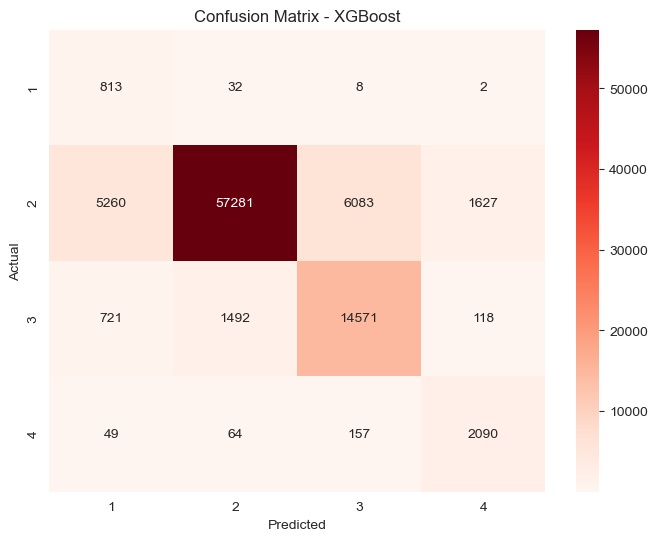

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [38]:
def predict_accident(
    description,
    hour,
    month,
    weekday,
    temperature,
    humidity,
    visibility,
    wind_speed
):
    # Clean text
    text = str(description)
    text = ''.join(
        char if char.isalpha() or char.isspace()
        else ' '
        for char in text.lower()
    )

    words = text.split()

    cleaned_text = ' '.join(
        [
            ps.stem(word)
            for word in words
            if word not in all_stopwords
            and word not in ROAD_WORDS
        ]
    )

    # Vectorize text
    text_vec = vectorizer.transform([cleaned_text])

    # Structured features
    input_num = pd.DataFrame([{
        "Hour": hour,
        "Month": month,
        "Weekday": weekday,
        "Temperature(F)": temperature,
        "Humidity(%)": humidity,
        "Visibility(mi)": visibility,
        "Wind_Speed(mph)": wind_speed
    }])

    # Boolean features
    for col in bool_cols:
        input_num[col] = 0

    # Keep same feature order as training
    input_num = input_num[feature_cols]

    # Scale
    input_scaled = scaler.transform(input_num)

    # Feature Fusion
    input_combined = hstack(
        [text_vec, input_scaled]
    ).tocsr()

    # Prediction
    pred_encoded = xgb_model.predict(input_combined)[0]

    pred_label = le.inverse_transform(
        [int(pred_encoded)]
    )[0]

    return pred_label

In [ ]:
scenarios = [

    {
        "name": "Class 1: Minor Incident",
        "desc": "minor fender bender with no injuries, vehicles moved to shoulder",
        "hour": 10,
        "month": 5,
        "weekday": 1,
        "temperature": 72,
        "humidity": 45,
        "visibility": 10,
        "wind_speed": 5
    },

    {
        "name": "Class 2: Typical Traffic Delay",
        "desc": "accident on right lane, causing moderate traffic congestion",
        "hour": 8,
        "month": 3,
        "weekday": 0,
        "temperature": 65,
        "humidity": 60,
        "visibility": 8,
        "wind_speed": 10
    },

    {
        "name": "Class 3: Severe Multi-Lane Crash",
        "desc": "Accident on I-35W Northbound from Exit 25B County Hwy-19 County Road D to Exit 26 County Road E2.",
        "hour": 18,
        "month": 12,
        "weekday": 4,
        "temperature": 40,
        "humidity": 80,
        "visibility": 3,
        "wind_speed": 18
    },

    {
        "name": "Class 4: Critical Fatal Crash",
        "desc": "fatal crash involving multiple vehicles highway closed in both directions",
        "hour": 2,
        "month": 1,
        "weekday": 6,
        "temperature": 28,
        "humidity": 95,
        "visibility": 1,
        "wind_speed": 25
    }

]

print("Running Stress Tests")
print("=" * 50)

for s in scenarios:

    pred = predict_accident(
        description=s["desc"],
        hour=s["hour"],
        month=s["month"],
        weekday=s["weekday"],
        temperature=s["temperature"],
        humidity=s["humidity"],
        visibility=s["visibility"],
        wind_speed=s["wind_speed"]
    )

    print(f"Scenario: {s['name']}")
    print(f"Prediction: Severity {pred}")
    print("-" * 40)

Running Stress Tests
Scenario: Class 1: Minor Incident
Prediction: Severity 2
----------------------------------------
Scenario: Class 2: Typical Traffic Delay
Prediction: Severity 2
----------------------------------------
Scenario: Class 3: Severe Multi-Lane Crash
Prediction: Severity 3
----------------------------------------
Scenario: Class 4: Critical Fatal Crash
Prediction: Severity 4
----------------------------------------


In [40]:
import joblib
import os
models_dir = r'C:\Users\NoteBook\Desktop\traffic_ai_system\models'
joblib.dump(xgb_model, os.path.join(models_dir, 'xgb_model.joblib'))
joblib.dump(vectorizer, os.path.join(models_dir, 'vectorizer.joblib'))
joblib.dump(scaler, os.path.join(models_dir, 'scaler.joblib'))
joblib.dump(le, os.path.join(models_dir, 'label_encoder.joblib'))
joblib.dump(feature_cols, os.path.join(models_dir, 'feature_cols.joblib'))
print("All model artifacts saved successfully in:", models_dir)

All model artifacts saved successfully in: C:\Users\NoteBook\Desktop\traffic_ai_system\models
